# Discrimination by horizon across regimes

How does each baseline's ROC-AUC vary with the prediction horizon in different
macro/credit regimes? Uses the per-horizon **walk-forward** scores saved by the three training
notebooks (`results/models/<model>_predictions.parquet`), so no model is refit
here — this is pure evaluation.

Regimes (calendar years of the feature date *t*; every regime is out-of-sample
under the walk-forward protocol):

| Regime | Years | Split |
|---|---|---|
| GFC | 2007–2009 | val-era |
| Recovery | 2010–2012 | val-era |
| Expansion | 2013–2019 | test |
| COVID | 2020–2021 | test |
| Tightening | 2022–2025 | test |

**Caveat:** XGBoost hyperparameters and tree counts were selected on 2007–2012,
so the GFC and Recovery numbers for the XGB models retain that one in-window
choice (the scores themselves come from models trained only on earlier data).
CHS has no selected quantities anywhere.

Cells with fewer than 10 defaulters are blanked (AUC too noisy to interpret).
Outputs: two PNGs in `results/figures/` and a tidy CSV in `results/models/`.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score

import baseline_utils as bu

MODELS = {'chs_logit': 'CHS logit',
          'xgb_node_features': 'XGBoost (node)',
          'xgb_neighbor_features': 'XGBoost (+neighbors)'}

REGIMES = [('GFC', 2007, 2009), ('Recovery', 2010, 2012),
           ('Expansion', 2013, 2019), ('COVID', 2020, 2021),
           ('Tightening', 2022, 2025)]

MIN_POS = 10
FIG_DIR = bu.PROJECT_ROOT / 'results' / 'figures'

# labels + per-model scores on one frame
panel = bu.load_panel()
label_cols = [bu.label_col(h) for h in bu.HORIZONS]
df = panel[['gvkey', 'datadate', 'year', 'split'] + label_cols].copy()
for key in MODELS:
    pred = pd.read_parquet(bu.RESULTS / f'{key}_predictions.parquet')
    pred = pred[['gvkey', 'datadate'] + [f'score_h{h}' for h in bu.HORIZONS]]
    pred.columns = ['gvkey', 'datadate'] + [f'{key}_h{h}' for h in bu.HORIZONS]
    df = df.merge(pred, on=['gvkey', 'datadate'], how='left')
df = df[df['year'] >= 2007]  # out-of-sample only
print(df.shape)

(516278, 36)


In [2]:
def cell_auc(sub, score_col, label_col):
    s = sub[[score_col, label_col]].dropna()
    if len(s) == 0 or s[label_col].sum() < MIN_POS or s[label_col].mean() == 1:
        return np.nan, int(s[label_col].sum()) if len(s) else 0
    return roc_auc_score(s[label_col], s[score_col]), int(s[label_col].sum())

rows = []
for name, y0, y1 in REGIMES:
    for h in bu.HORIZONS:
        sub = df[(df['year'] >= y0) & (df['year'] <= y1) & bu.horizon_mask(df, h)]
        for key in MODELS:
            auc, n_pos = cell_auc(sub, f'{key}_h{h}', bu.label_col(h))
            rows.append({'regime': name, 'years': f'{y0}-{y1}', 'horizon': h,
                         'model': key, 'roc_auc': auc, 'n_pos': n_pos})
regime_auc = pd.DataFrame(rows)
regime_auc.to_csv(bu.RESULTS / 'regime_horizon_auc.csv', index=False)

# positives per regime x horizon (same for all models up to score coverage)
regime_auc[regime_auc['model'] == 'xgb_node_features'].pivot(
    index='horizon', columns='regime', values='n_pos')[
    [r[0] for r in REGIMES]]

regime,GFC,Recovery,Expansion,COVID,Tightening
horizon,,,,,
1,79,38,105,39,27
2,223,98,265,77,81
3,396,174,453,110,147
4,577,249,662,142,227
5,763,329,885,175,317
6,958,415,1109,221,390
7,1153,500,1331,271,445
8,1339,583,1551,333,476


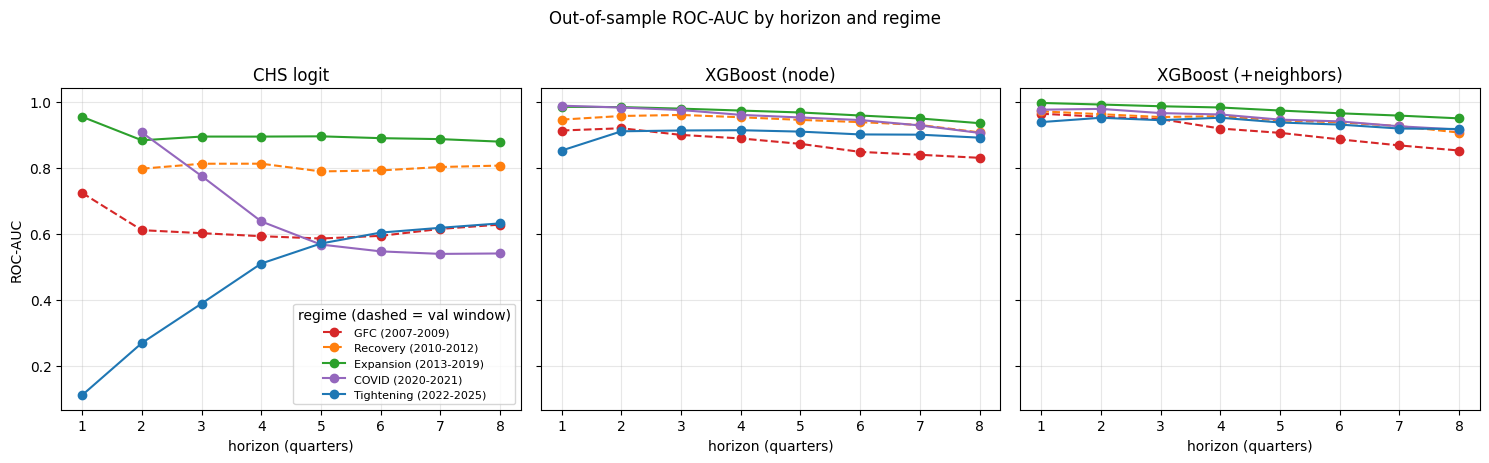

In [3]:
# Figure 1 — term structure of ROC-AUC, one line per regime, one panel per model
regime_colors = {'GFC': '#d62728', 'Recovery': '#ff7f0e', 'Expansion': '#2ca02c',
                 'COVID': '#9467bd', 'Tightening': '#1f77b4'}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (key, label) in zip(axes, MODELS.items()):
    for name, y0, y1 in REGIMES:
        sub = regime_auc[(regime_auc['model'] == key) & (regime_auc['regime'] == name)]
        ls = '--' if name in ('GFC', 'Recovery') else '-'   # dashed = val window
        ax.plot(sub['horizon'], sub['roc_auc'], marker='o', ls=ls,
                color=regime_colors[name], label=f'{name} ({y0}-{y1})')
    ax.set_title(label)
    ax.set_xlabel('horizon (quarters)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('ROC-AUC')
axes[0].legend(fontsize=8, title='regime (dashed = val window)')
fig.suptitle('Out-of-sample ROC-AUC by horizon and regime', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'baseline_auc_by_horizon_regime.png',
            dpi=150, bbox_inches='tight')
plt.show()

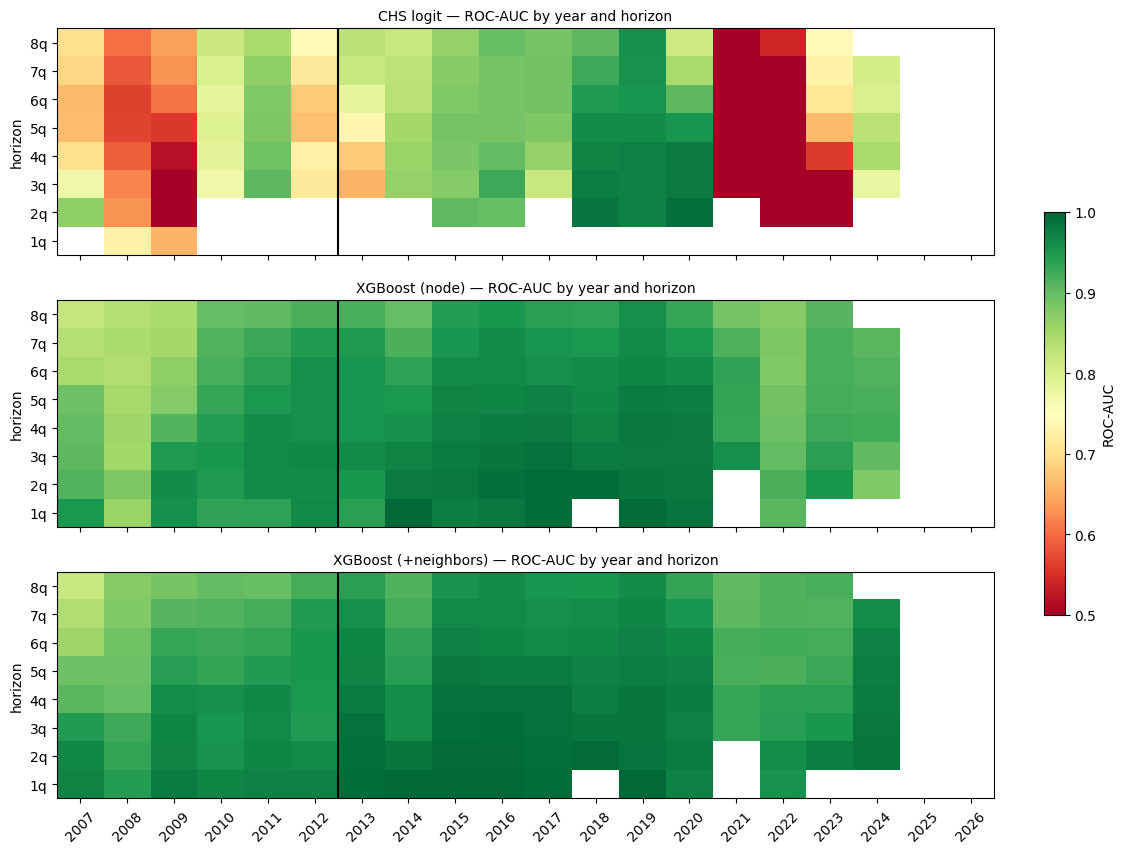

In [4]:
# Figure 2 — horizon x year heatmaps (annual cells are noisier; blanks = <10 defaulters)
years = sorted(df['year'].unique())
fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)
for ax, (key, label) in zip(axes, MODELS.items()):
    grid = np.full((len(bu.HORIZONS), len(years)), np.nan)
    for j, yr in enumerate(years):
        for i, h in enumerate(bu.HORIZONS):
            sub = df[(df['year'] == yr) & bu.horizon_mask(df, h)]
            grid[i, j], _ = cell_auc(sub, f'{key}_h{h}', bu.label_col(h))
    im = ax.imshow(grid, aspect='auto', vmin=0.5, vmax=1.0, cmap='RdYlGn',
                   origin='lower')
    ax.set_yticks(range(len(bu.HORIZONS)), [f'{h}q' for h in bu.HORIZONS])
    ax.set_ylabel('horizon')
    ax.set_title(f'{label} — ROC-AUC by year and horizon', fontsize=10)
    ax.axvline(years.index(2013) - 0.5, color='black', lw=1.5)  # val | test
axes[-1].set_xticks(range(len(years)), years, rotation=45)
fig.colorbar(im, ax=axes, label='ROC-AUC', fraction=0.02)
fig.savefig(FIG_DIR / 'baseline_auc_heatmap_year_horizon.png',
            dpi=150, bbox_inches='tight')
plt.show()

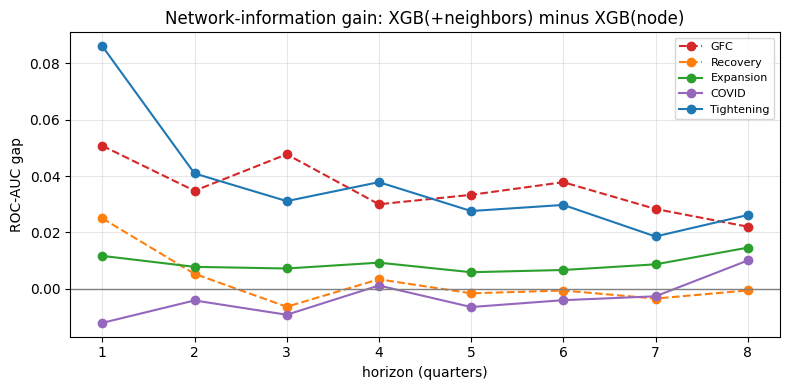

regime,GFC,Recovery,Expansion,COVID,Tightening
horizon,,,,,
1,0.0508,0.0250,0.0117,-0.0121,0.0861
2,0.0348,0.0053,0.0078,-0.0041,0.0410
3,0.0478,-0.0064,0.0072,-0.0092,0.0311
4,0.0300,0.0034,0.0093,0.0012,0.0379
5,0.0334,-0.0016,0.0059,-0.0065,0.0276
6,0.0379,-0.0006,0.0067,-0.0040,0.0298
7,0.0283,-0.0035,0.0087,-0.0027,0.0186
8,0.0221,-0.0006,0.0146,0.0101,0.0262


In [5]:
# Where does network information help? Gap = (+neighbors) - (node only), per regime x horizon
gap = (regime_auc.pivot_table(index=['regime', 'horizon'], columns='model',
                              values='roc_auc')
       .assign(gap=lambda d: d['xgb_neighbor_features'] - d['xgb_node_features'])
       .reset_index())
gap_tbl = gap.pivot(index='horizon', columns='regime', values='gap')[
    [r[0] for r in REGIMES]]

fig, ax = plt.subplots(figsize=(8, 4))
for name, y0, y1 in REGIMES:
    ls = '--' if name in ('GFC', 'Recovery') else '-'
    ax.plot(gap_tbl.index, gap_tbl[name], marker='o', ls=ls,
            color=regime_colors[name], label=name)
ax.axhline(0, color='gray', lw=1)
ax.set_xlabel('horizon (quarters)'); ax.set_ylabel('ROC-AUC gap')
ax.set_title('Network-information gain: XGB(+neighbors) minus XGB(node)')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(FIG_DIR / 'network_gain_by_horizon_regime.png',
            dpi=150, bbox_inches='tight')
plt.show()
gap_tbl.round(4)

In [6]:
# Full regime x horizon ROC-AUC table (all models)
tbl = regime_auc.pivot_table(index=['model', 'horizon'], columns='regime',
                             values='roc_auc')[[r[0] for r in REGIMES]]
tbl.round(4)

regime                            GFC  Recovery  Expansion   COVID  Tightening
model                 horizon                                                 
chs_logit             1        0.7234       NaN     0.9539     NaN      0.1114
                      2        0.6108    0.7968     0.8829  0.9066      0.2692
                      3        0.6017    0.8119     0.8941  0.7747      0.3885
                      4        0.5925    0.8120     0.8941  0.6372      0.5098
                      5        0.5855    0.7886     0.8948  0.5672      0.5704
                      6        0.5936    0.7916     0.8893  0.5466      0.6034
                      7        0.6146    0.8020     0.8864  0.5389      0.6179
                      8        0.6276    0.8063     0.8787  0.5402      0.6313
xgb_neighbor_features 1        0.9633    0.9705     0.9959  0.9755      0.9380
                      2        0.9541    0.9618     0.9911  0.9779      0.9510
                      3        0.9469    0.9533     0.9859  0.9652      0.9437
                      4        0.9184    0.9560     0.9822  0.9610      0.9512
                      5        0.9053    0.9430     0.9729  0.9454      0.9367
                      6        0.8856    0.9372     0.9646  0.9401      0.9304
                      7        0.8673    0.9259     0.9576  0.9252      0.9185
                      8        0.8519    0.9062     0.9492  0.9152      0.9170
xgb_node_features     1        0.9125    0.9454     0.9842  0.9876      0.8518
                      2        0.9193    0.9565     0.9833  0.9820      0.9101
                      3        0.8992    0.9596     0.9787  0.9744      0.9125
                      4        0.8884    0.9526     0.9729  0.9598      0.9133
                      5        0.8720    0.9446     0.9670  0.9519      0.9091
                      6        0.8477    0.9378     0.9579  0.9442      0.9006
                      7        0.8390    0.9293     0.9489  0.9279      0.8999
                      8        0.8298    0.9067     0.9346  0.9052      0.8909

## Robustness: bankruptcy-only labels

The event *source* composition changes sharply in 2022: LoPucki's bankruptcy
database stops being updated, and the remaining Compustat deletion-reason
events are dominated by `liquidation` — a bucket that includes royalty-trust
wind-downs, shell/merger-corp dissolutions, delisted foreign ADRs, and solvent
voluntary liquidations. Those entities genuinely *were* financially safe, so a
model that correctly ranks them safe gets a sub-0.5 AUC against those labels
(this is what drives the CHS collapse in the Tightening regime above).

Here every model's scores are re-evaluated against **bankruptcy-only** labels
(`default_type != 'liquidation'`), with firm-quarters that are positive *only*
because of a liquidation event **excluded** from the sample (rather than
relabelled as negatives, since their true credit status is ambiguous).
Models are *not* refit — this isolates the labelling effect.

In [7]:
# bankruptcy-only labels per horizon (same phase4 rule, filtered events)
de = pd.read_parquet(bu.CLEAN / 'default_events.parquet')
de['default_date'] = pd.to_datetime(de['default_date'])
bk = de[de['default_type'] != 'liquidation']
first_bk = bk.groupby('gvkey')['default_date'].min()
days_bk = (df['gvkey'].map(first_bk) - df['datadate']).dt.days

for h in bu.HORIZONS:
    df[f'bk_next_{h}q'] = ((days_bk > 0) &
                           (days_bk <= bu.HORIZON_DAYS[h])).astype('int8')
    both = df[bu.label_col(h)]
    print(f'h={h}q: positives all-events={int(both.sum()):,}  '
          f'bankruptcy-only={int(df[f"bk_next_{h}q"].sum()):,}')

h=1q: positives all-events=288  bankruptcy-only=252
h=2q: positives all-events=746  bankruptcy-only=603
h=3q: positives all-events=1,288  bankruptcy-only=1,025
h=4q: positives all-events=1,872  bankruptcy-only=1,480
h=5q: positives all-events=2,493  bankruptcy-only=1,961
h=6q: positives all-events=3,137  bankruptcy-only=2,457
h=7q: positives all-events=3,776  bankruptcy-only=2,952
h=8q: positives all-events=4,403  bankruptcy-only=3,443


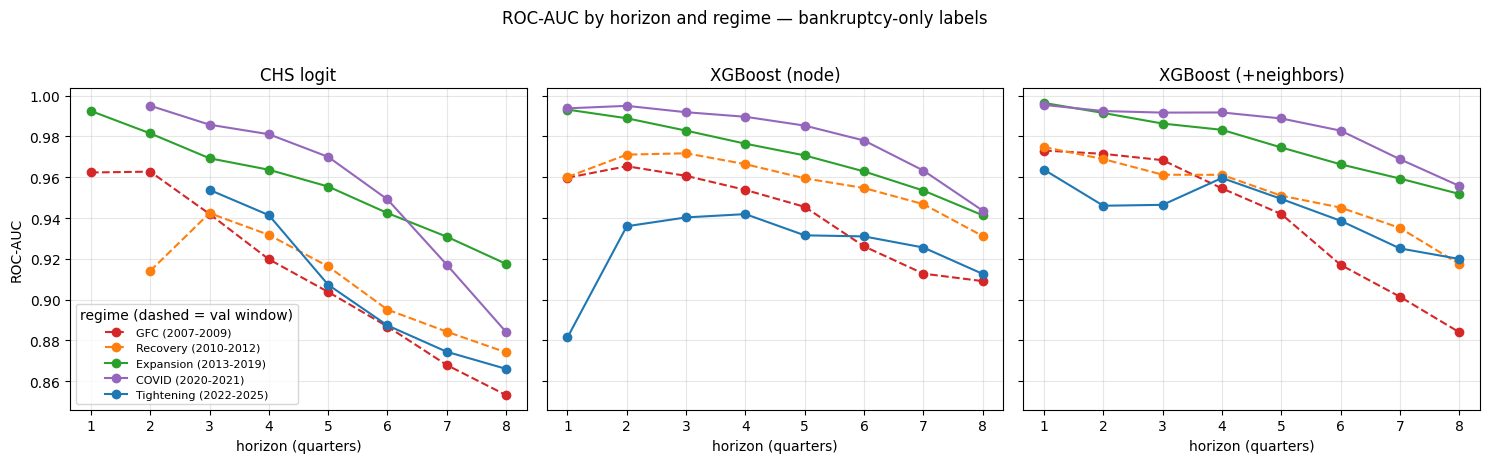

In [8]:
rows = []
for name, y0, y1 in REGIMES:
    for h in bu.HORIZONS:
        sub = df[(df['year'] >= y0) & (df['year'] <= y1) & bu.horizon_mask(df, h)]
        # drop liquidation-only positives (ambiguous rows)
        sub = sub[~((sub[bu.label_col(h)] == 1) & (sub[f'bk_next_{h}q'] == 0))]
        for key in MODELS:
            auc, n_pos = cell_auc(sub, f'{key}_h{h}', f'bk_next_{h}q')
            rows.append({'regime': name, 'horizon': h, 'model': key,
                         'roc_auc': auc, 'n_pos': n_pos})
regime_auc_bk = pd.DataFrame(rows)
regime_auc_bk.to_csv(bu.RESULTS / 'regime_horizon_auc_bankruptcy_only.csv',
                     index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
for ax, (key, label) in zip(axes, MODELS.items()):
    for name, y0, y1 in REGIMES:
        sub = regime_auc_bk[(regime_auc_bk['model'] == key) &
                            (regime_auc_bk['regime'] == name)]
        ls = '--' if name in ('GFC', 'Recovery') else '-'
        ax.plot(sub['horizon'], sub['roc_auc'], marker='o', ls=ls,
                color=regime_colors[name], label=f'{name} ({y0}-{y1})')
    ax.set_title(label)
    ax.set_xlabel('horizon (quarters)')
    ax.grid(alpha=0.3)
axes[0].set_ylabel('ROC-AUC')
axes[0].legend(fontsize=8, title='regime (dashed = val window)')
fig.suptitle('ROC-AUC by horizon and regime — bankruptcy-only labels', y=1.02)
plt.tight_layout()
fig.savefig(FIG_DIR / 'baseline_auc_by_horizon_regime_bankruptcy_only.png',
            dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Tightening regime before/after the label fix, side by side
cmp = pd.concat([
    regime_auc[regime_auc['regime'] == 'Tightening']
        .pivot(index='horizon', columns='model', values='roc_auc')
        .add_suffix(' (all events)'),
    regime_auc_bk[regime_auc_bk['regime'] == 'Tightening']
        .pivot(index='horizon', columns='model', values='roc_auc')
        .add_suffix(' (bankruptcy only)'),
], axis=1).sort_index(axis=1)
cmp.round(4)

model,chs_logit (all events),chs_logit (bankruptcy only),xgb_neighbor_features (all events),xgb_neighbor_features (bankruptcy only),xgb_node_features (all events),xgb_node_features (bankruptcy only)
horizon,,,,,,
1,0.1114,NaN,0.9380,0.9637,0.8518,0.8815
2,0.2692,NaN,0.9510,0.9460,0.9101,0.9360
3,0.3885,0.9538,0.9437,0.9465,0.9125,0.9403
4,0.5098,0.9414,0.9512,0.9596,0.9133,0.9419
5,0.5704,0.9073,0.9367,0.9494,0.9091,0.9315
6,0.6034,0.8874,0.9304,0.9386,0.9006,0.9310
7,0.6179,0.8745,0.9185,0.9251,0.8999,0.9256
8,0.6313,0.8661,0.9170,0.9200,0.8909,0.9126
